In [1]:
PATH_BERLIN = r"C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement"
PATH_BEIJING = r"C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Beijing"
annotations_out_Beijing = r"C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Beijing\derivatives"
annotations_out_Berlin = r"C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\derivatives"

In [2]:
import os
import mne 
import mne_bids
from bids import BIDSLayout
import numpy as np
from mayavi import mlab
from matplotlib import pyplot as plt

%matplotlib qt

os.environ['ETS_TOOLKIT'] = 'qt4'
os.environ['QT_API'] = 'pyqt5'

multiple 'tvtk.toolkits' plugins found for toolkit 'qt4': tvtk.pyface.ui.qt4.init, tvtk.pyface.ui.qt4.init


In [3]:
layout = BIDSLayout(PATH_BEIJING)
subjects = layout.get_subjects()
run_files_Beijing = []
for sub in subjects:
    if sub != "FOG013":
        try:
            run_files_Beijing.append(layout.get(subject=sub, task='ButtonPress', extension='.vhdr')[0])
        except:
            pass

layout = BIDSLayout(PATH_BERLIN)
run_files_Berlin = layout.get(extension='.vhdr')

C:\Users\ICN_admin\AppData\Roaming\Python\Python39\site-packages\bids\layout\models.py:148: FutureWarning: The 'extension' entity currently excludes the leading dot ('.'). As of version 0.14.0, it will include the leading dot. To suppress this warning and include the leading dot, use `bids.config.set_option('extension_initial_dot', True)`.
  warnings.warn("The 'extension' entity currently excludes the leading dot ('.'). "


In [4]:
def read_BIDS_data(PATH_RUN, BIDS_PATH):
    """Given a run path and bids data path, read the respective data
    Parameters
    ----------
    PATH_RUN : string
    BIDS_PATH : string
    Returns
    -------
    raw_arr : mne.io.RawArray
    raw_arr_data : np.ndarray
    fs : int
    line_noise : int
    """
    entities = mne_bids.get_entities_from_fname(PATH_RUN)

    bids_path = mne_bids.BIDSPath(subject=entities["subject"],
                                  session=entities["session"],
                                  task=entities["task"],
                                  run=entities["run"],
                                  acquisition=entities["acquisition"],
                                  datatype="ieeg", root=BIDS_PATH)

    raw_arr = mne_bids.read_raw_bids(bids_path)

    return (raw_arr, raw_arr.get_data(), int(np.ceil(raw_arr.info["sfreq"])),
            int(raw_arr.info["line_freq"]))

In [5]:
run_files_Berlin

[<BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-002\ses-EphysMedOff01\ieeg\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr'>,
 <BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-002\ses-EphysMedOff02\ieeg\sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr'>,
 <BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-002\ses-EphysMedOff03\ieeg\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr'>,
 <BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-002\ses-EphysMedOff03\ieeg\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg.vhdr'>,
 <BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-003\ses-EphysMedOff01\ieeg\sub-003_ses-EphysMedOff01_task-Se

In [47]:
run_files_Beijing[4]

<BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Beijing\sub-FOGC001\ses-EphysMedOff\ieeg\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg.vhdr'>

In [42]:
run_files_Berlin[17]

<BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-005\ses-EphysMedOn02\ieeg\sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg.vhdr'>

In [38]:
file_name = run_files_Berlin[17]
raw_arr, data, sfreq, line_noise = read_BIDS_data(file_name, PATH_BERLIN)

print(file_name)

# read annotations, IF DONE ALREADY
# annot = mne.read_annotations(os.path.join(annotations_out_Beijing, file_name.filename[:-5]+".txt"))
#craw_arr.set_annotations(annot)

print(raw_arr.ch_names)

Extracting parameters from C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-005\ses-EphysMedOn02\ieeg\sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-005\ses-EphysMedOn02\ieeg\sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_events.tsv.
Reading channel info from C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-005\ses-EphysMedOn02\ieeg\sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_channels.tsv.
Reading in coordinate system frame Other: None.
Reading electrode coords from C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-005\ses-EphysMedOn02\ieeg\sub-005_ses-EphysMedOn02_space-MNI152NLin2009bAsym_electrodes.tsv.
The read in electrodes file is: 
 [('name', ['ECOG_R_1_SMC_AT', 'ECOG_R_2_SMC_AT', '

<ipython-input-4-aa3ae040c6dd>:23: RuntimeWarning: Defaulting coordinate frame to unknown from coordinate system input Other
  raw_arr = mne_bids.read_raw_bids(bids_path)
<ipython-input-4-aa3ae040c6dd>:23: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw_arr = mne_bids.read_raw_bids(bids_path)
<ipython-input-4-aa3ae040c6dd>:23: RuntimeWarning: DigMontage is only a subset of info. There are 3 channel positions not present in the DigMontage. The required channels are:

['LFP_L_234_STN_MT', 'LFP_L_567_STN_MT', 'LFP_R_234_STN_MT'].

Consider using inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw_arr = mne_bids.read_raw_bids(bids_path)


<BIDSFile filename='C:\Users\ICN_admin\Documents\Decoding_Toolbox\Data\Berlin_VoluntaryMovement\sub-005\ses-EphysMedOn02\ieeg\sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg.vhdr'>
['LFP_R_1_STN_MT', 'LFP_R_2_STN_MT', 'LFP_R_3_STN_MT', 'LFP_R_4_STN_MT', 'LFP_R_5_STN_MT', 'LFP_R_6_STN_MT', 'LFP_R_7_STN_MT', 'LFP_R_8_STN_MT', 'LFP_L_1_STN_MT', 'LFP_L_234_STN_MT', 'LFP_L_567_STN_MT', 'LFP_L_8_STN_MT', 'ECOG_R_1_SMC_AT', 'ECOG_R_2_SMC_AT', 'ECOG_R_3_SMC_AT', 'ECOG_R_4_SMC_AT', 'ECOG_R_5_SMC_AT', 'ECOG_R_6_SMC_AT', 'EEG_Cz_TM', 'EEG_Fz_TM', 'EMG_R_BR_TM', 'EMG_L_BR_TM', 'ACC_R_X_D2_TM', 'ACC_R_Y_D2_TM', 'ACC_R_Z_D2_TM', 'ACC_L_X_D2_TM', 'ACC_L_Y_D2_TM', 'ACC_L_Z_D2_TM', 'ANALOG_R_ROTA_CH', 'rota_squared', 'LFP_R_234_STN_MT']


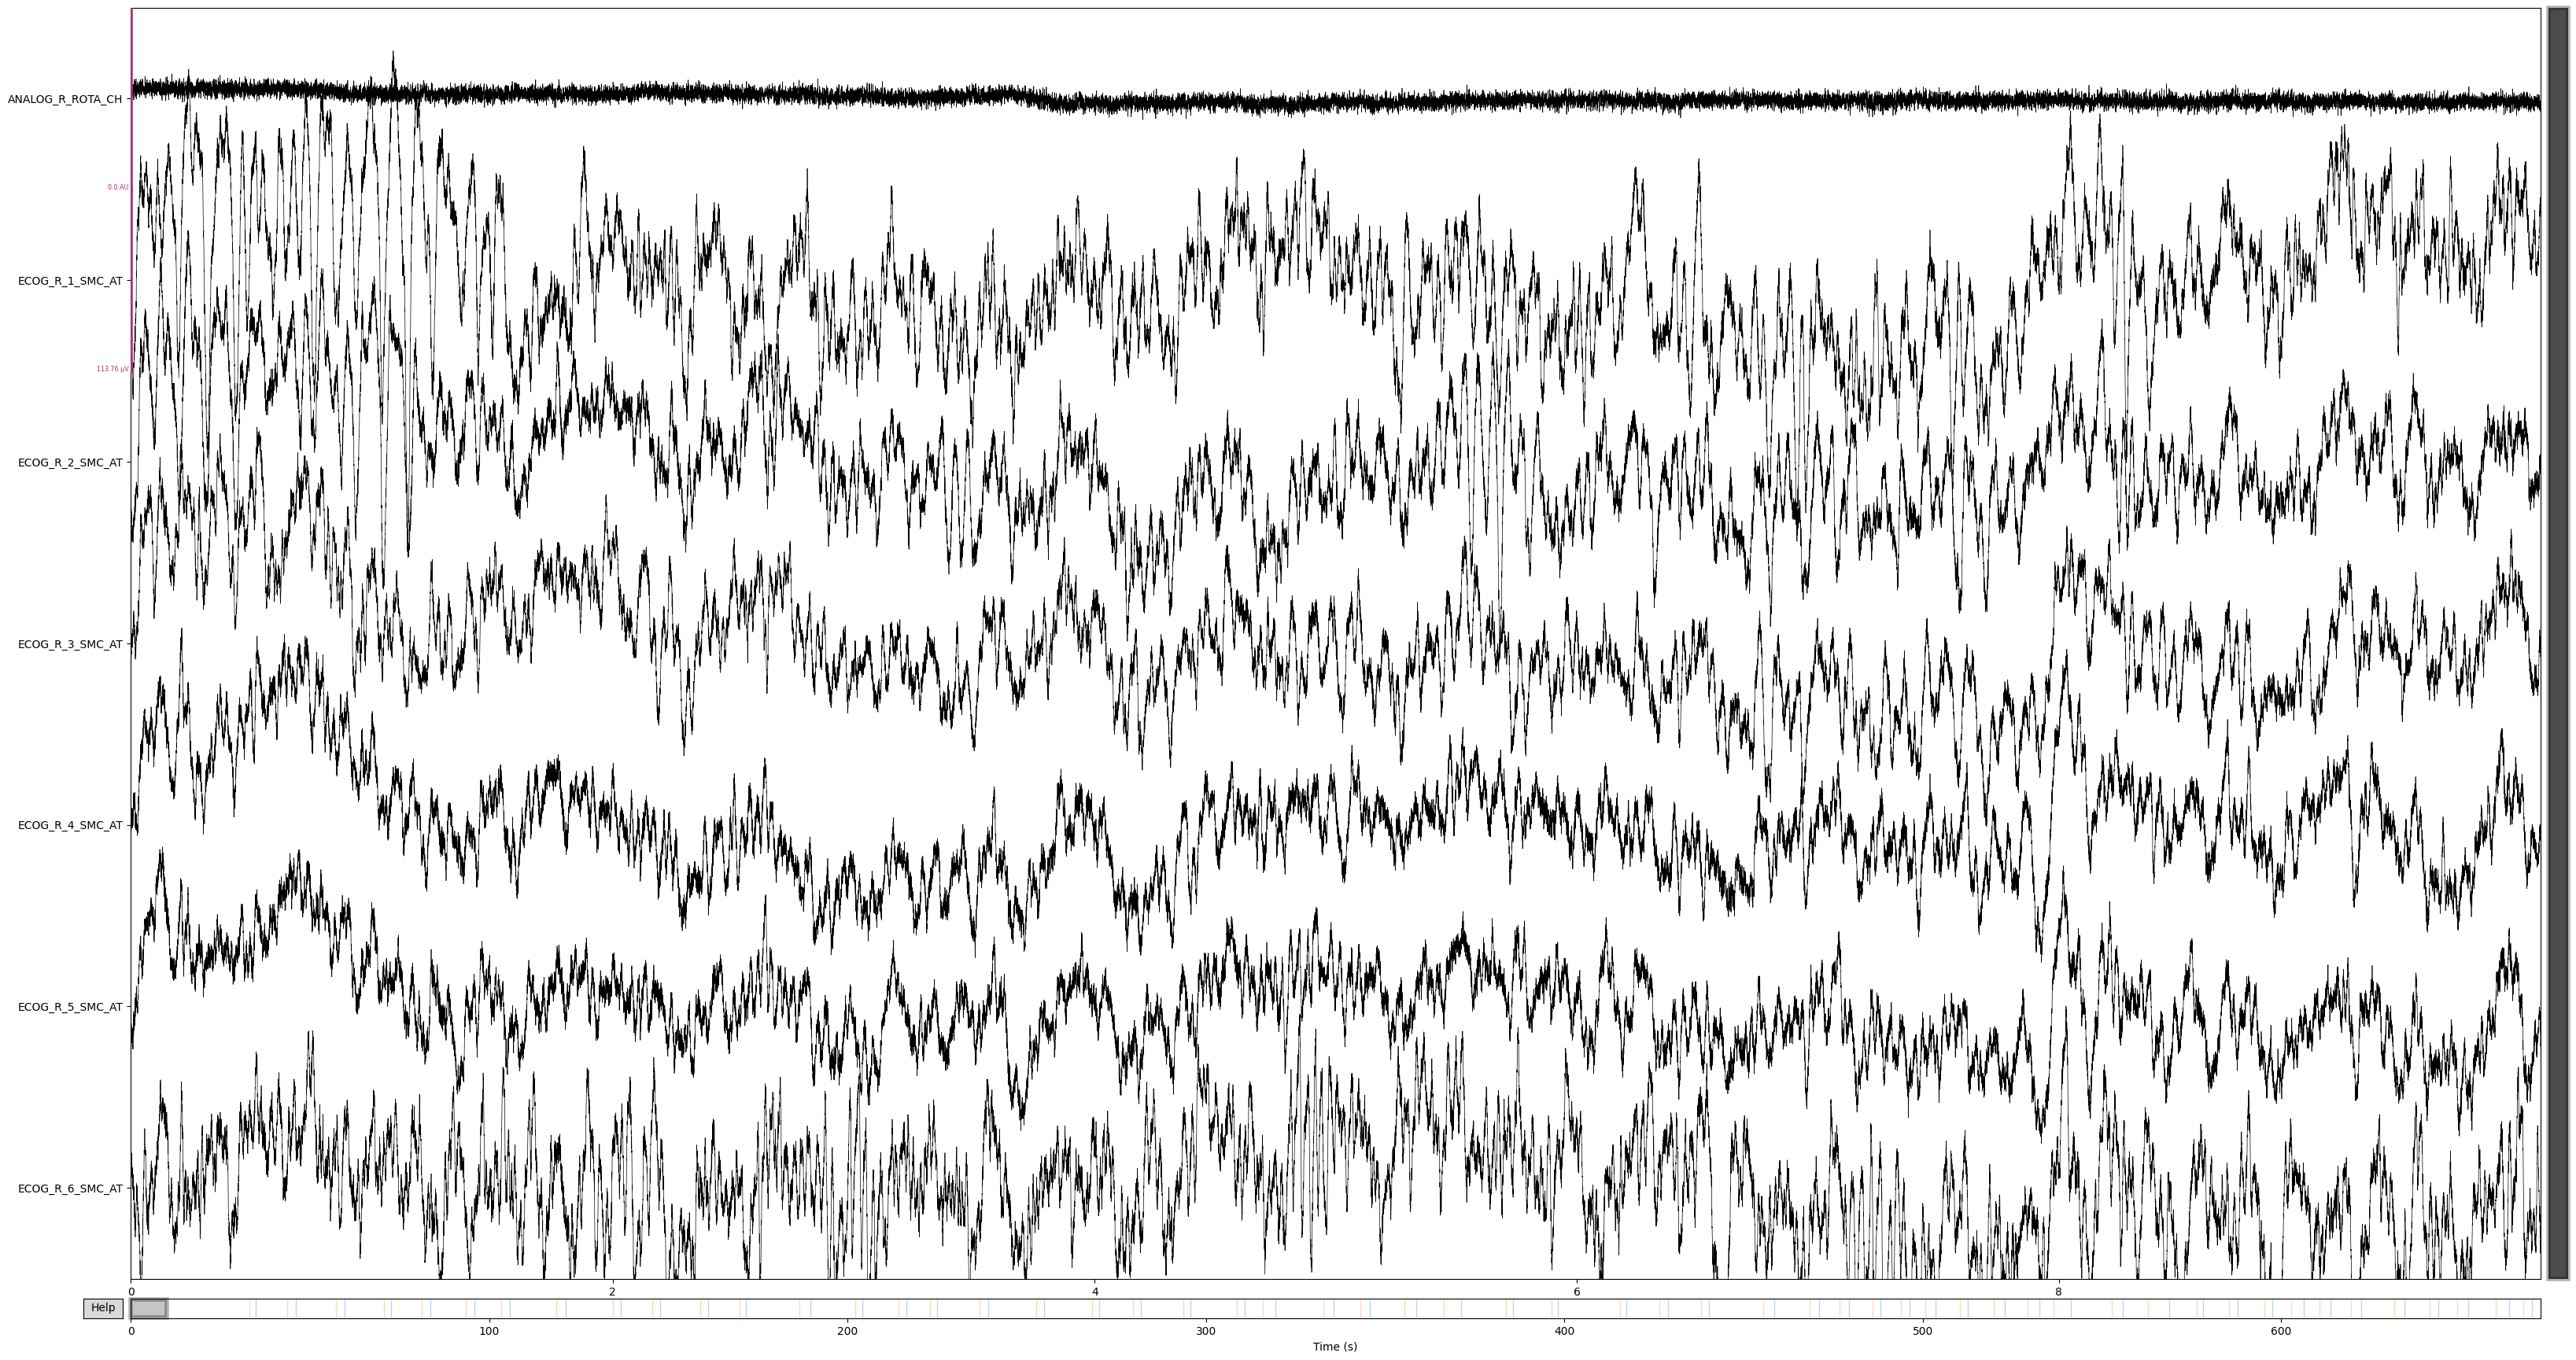

Channels marked as bad: none


In [39]:
l_ch = [ch for ch in raw_arr.ch_names if 'ECOG' in ch]
l_ch.append('ANALOG_R_ROTA_CH')

raw_arr.pick(l_ch).plot(scalings='auto')#, lowpass=200, highpass=2)

In [24]:
print(raw_arr.ch_names)

['ECOG_L_1_SMC_AT', 'ECOG_L_2_SMC_AT', 'ECOG_L_3_SMC_AT', 'ECOG_L_4_SMC_AT', 'ECOG_L_5_SMC_AT', 'ECOG_L_6_SMC_AT']


In [40]:
raw_arr.annotations.save(os.path.join(annotations_out_Berlin, file_name.filename[:-5]+'.txt'))

In [26]:
file_name.filename

'sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg.vhdr'

In [27]:
# delete data then lateron

data = raw_arr.get_data(reject_by_annotation='omit')

Omitting 51525 of 1312098 (3.93%) samples, retaining 1260573 (96.07%) samples.


Setting up band-pass filter from 2 - 2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 2.00, 200.00 Hz: -6.02, -6.02 dB



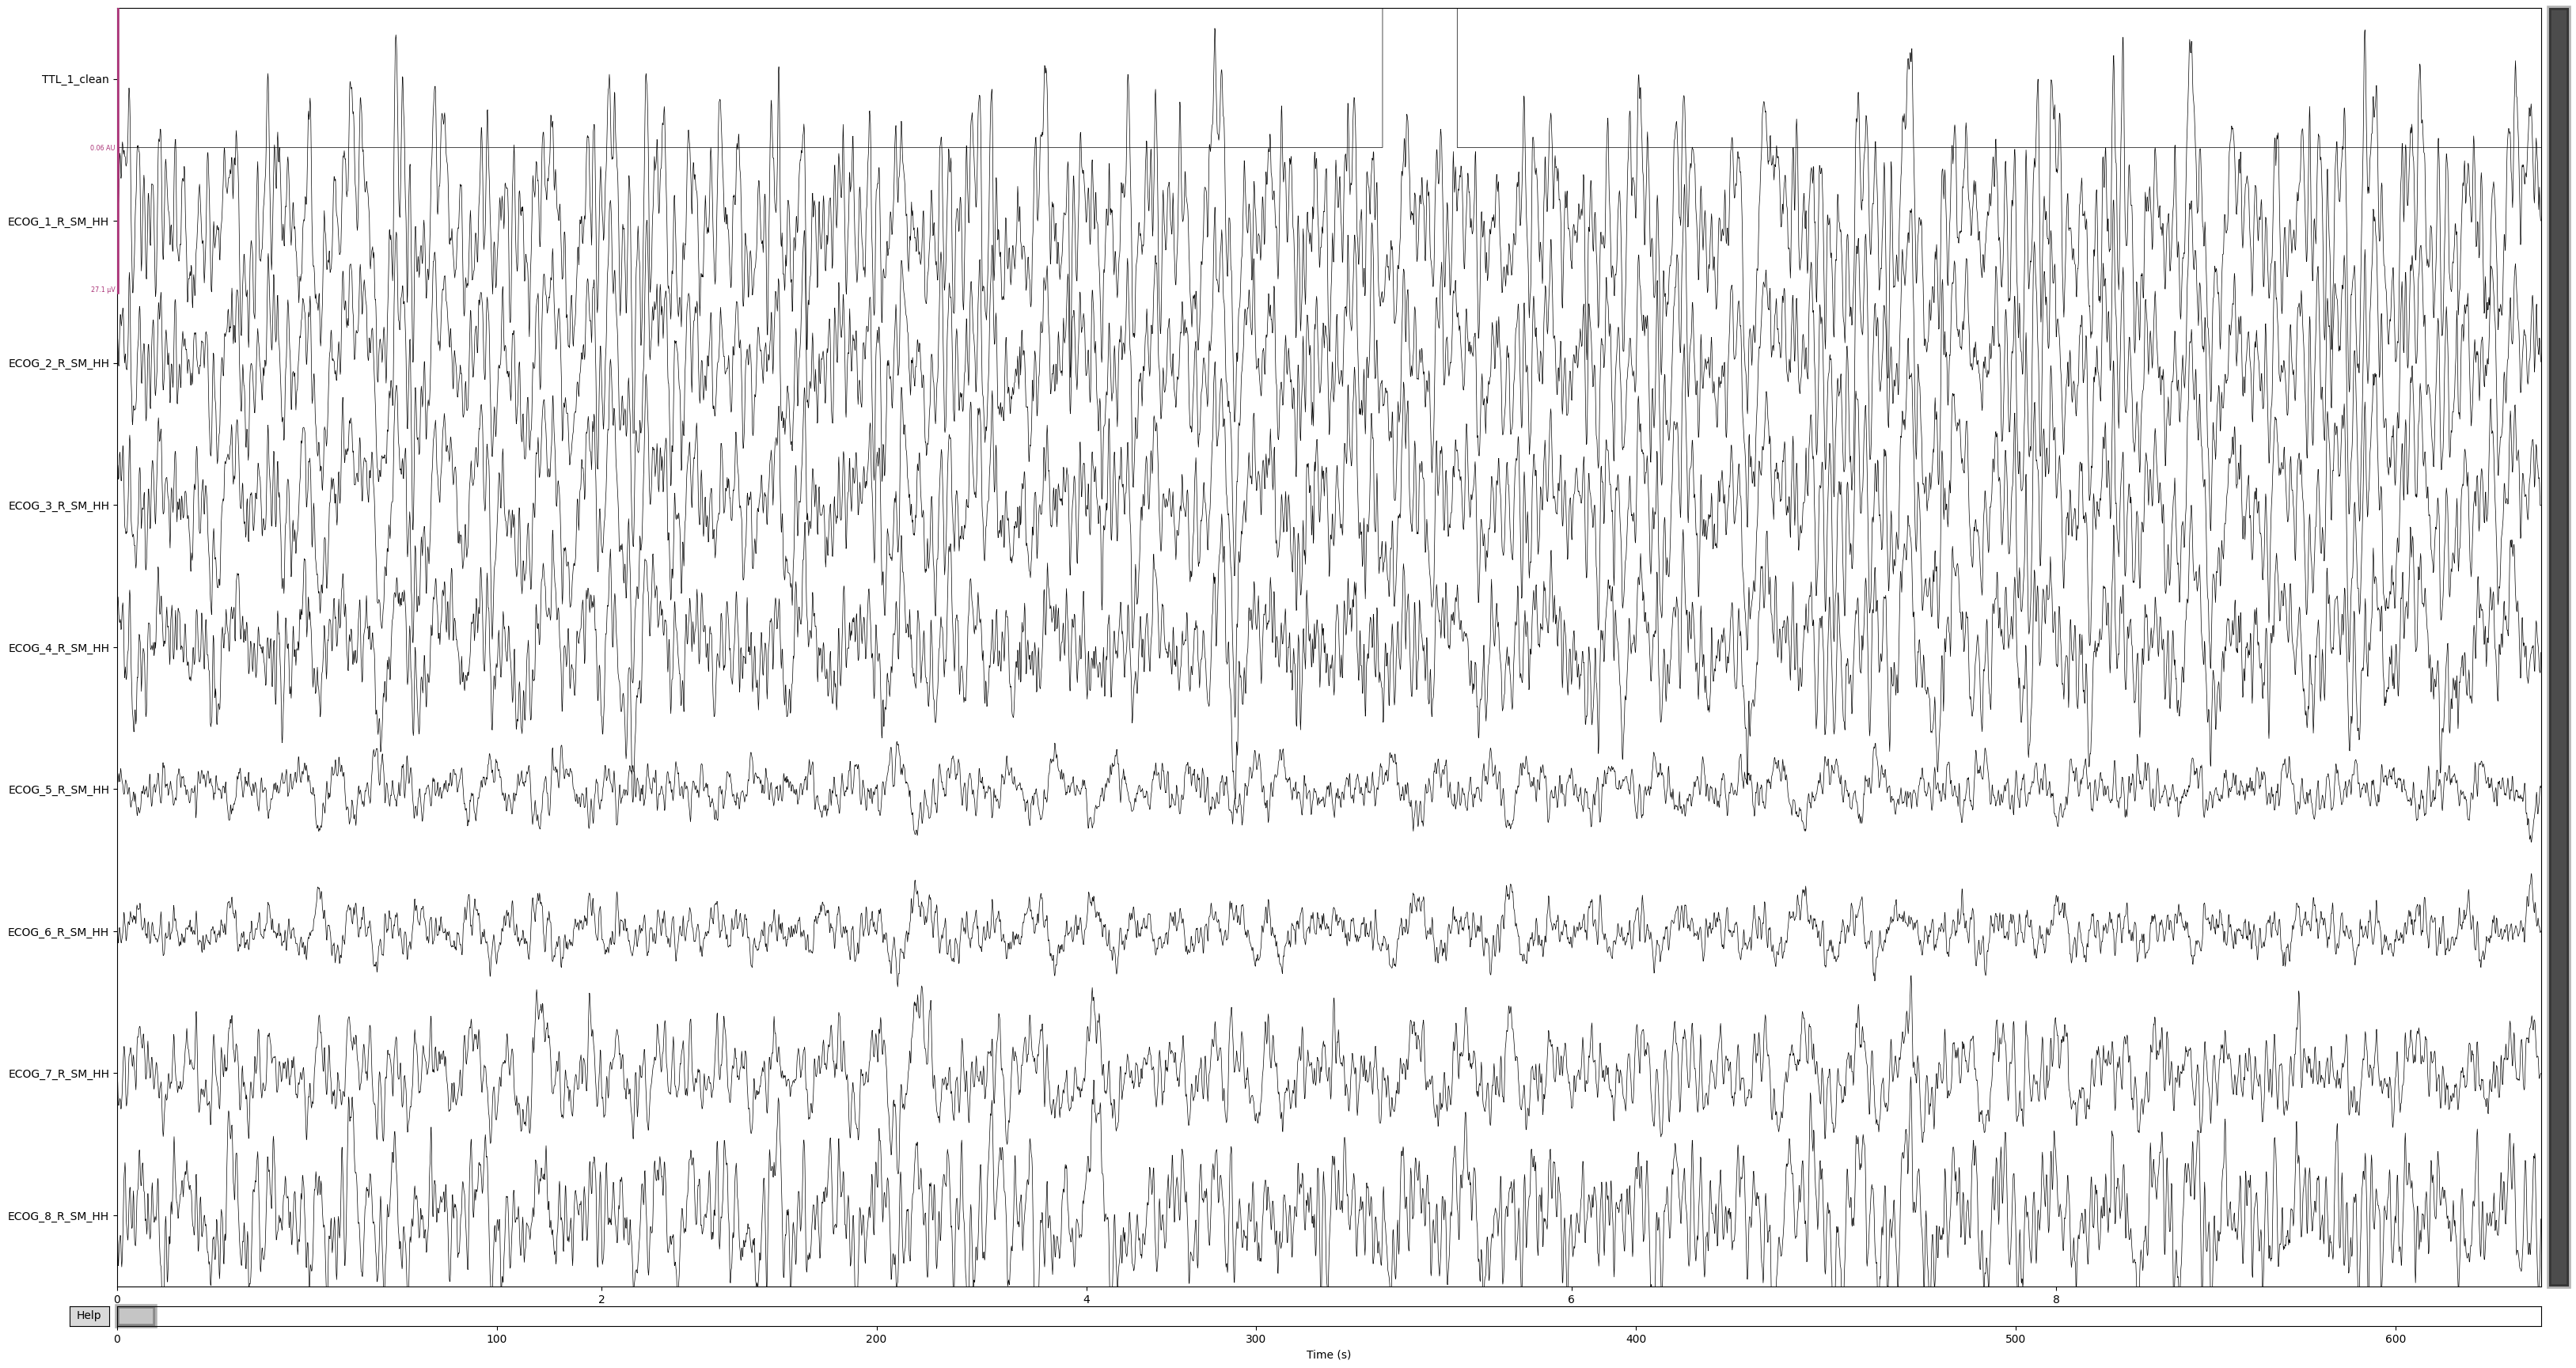

Channels marked as bad: none


In [12]:
raw_arr.pick(l_ch).plot(scalings='auto', lowpass=200, highpass=2)

#raw_arr.pick(['TTL_1_clean', 'ECOG_1_R_SM_HH', 'ECOG_2_R_SM_HH',
#             'ECOG_3_R_SM_HH', 'ECOG_4_R_SM_HH', 'ECOG_5_R_SM_HH', 
#             'ECOG_6_R_SM_HH', 'ECOG_7_R_SM_HH', 'ECOG_8_R_SM_HH']).plot(scalings='auto', lowpass=200, highpass=2)

In [62]:
len(raw_arr.ch_names)

36

In [79]:
raw_arr.ch_names[31]

'MISC_10_TTL'

In [68]:
raw_arr.times?

In [82]:
plt.plot(raw_arr.times, raw_arr.get_data()[-1,:])
plt.xlabel("Time [s]")
plt.title("Cleaned TTL signal")

Text(0.5, 1.0, 'Cleaned TTL signal')

In [39]:
raw_arr.annotations

<Annotations | 3 segments: BAD_Label (3)>

In [40]:
file_name.filename[:-5]

'sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg'

In [19]:
raw_arr.annotations.save(os.path.join(annotations_out_Beijing, file_name.filename[:-5]+'.txt'), overwrite=True)

Overwriting existing file.
